<a href="https://colab.research.google.com/github/Naveenyadav60000/AI-ML/blob/main/Day01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement

Clean, Explore & Engineer — Load the dataset and (a) identify and handle missing values, duplicates and obvious outliers, (b) perform EDA with at least 4 visualizations (distributions, correlations, group comparisons), and (c) engineer at least 2 new features that could help a future model. Summarize 5 key insights in markdown/comments.
Time limit: 60 minutes
Deliverables
Jupyter/Colab notebook (.ipynb) with cleaning, EDA and feature engineering steps
At least 4 charts (histogram, boxplot, correlation heatmap, bar/count plot, etc.)
A short written summary (5 bullet points) of the most interesting findings


https://colab.research.google.com/drive/1pwfBcN49F2yis9nbteyGrN2wLy0PVa3k

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Titanic dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check the dataset:

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Check missing values

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Handle missing values

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop("Cabin", axis=1, inplace=True)

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Check duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

Check obvious outliers

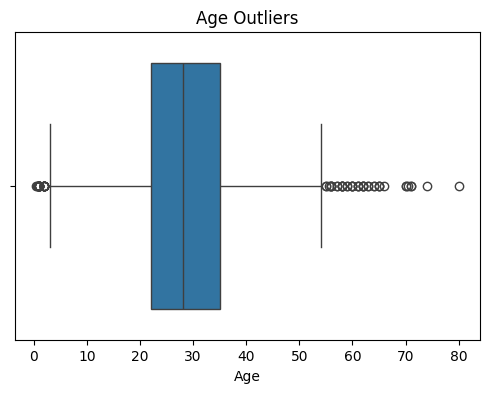

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.show()

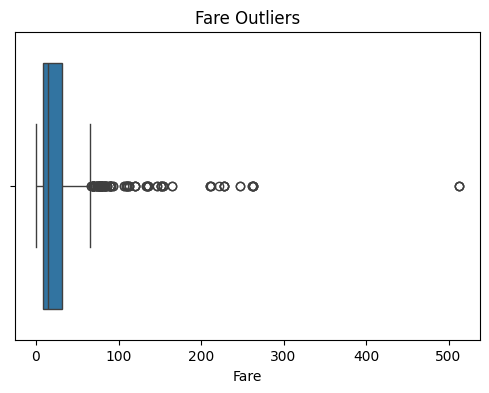

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

EDA — Visualization

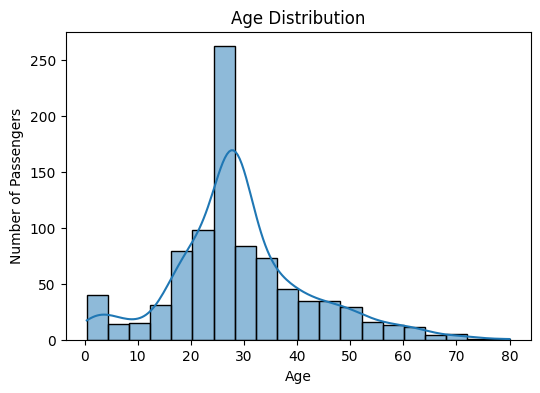

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

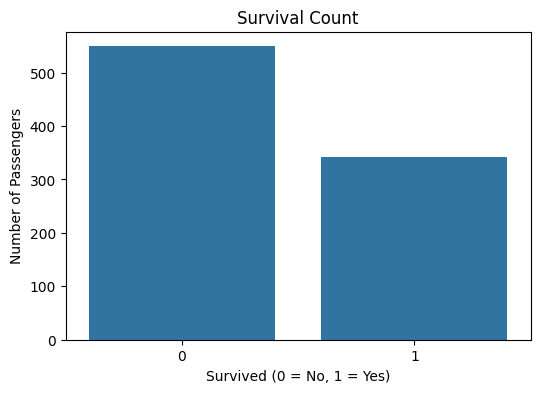

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

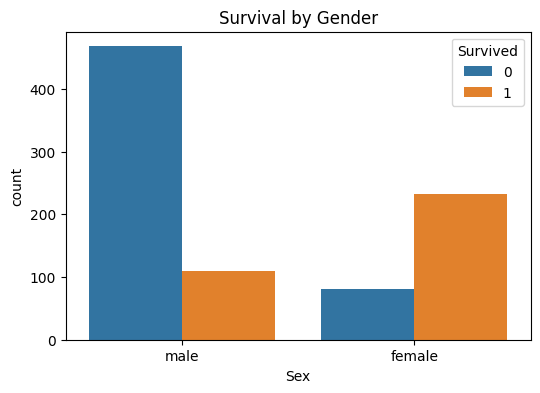

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

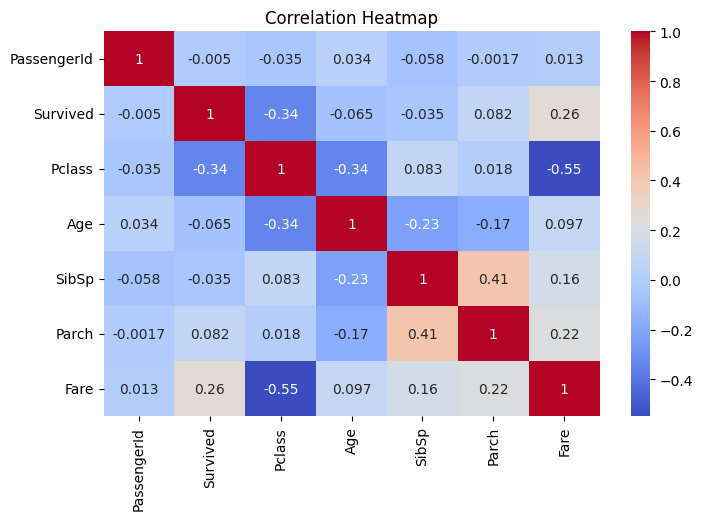

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

Feature Engineering

In [17]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [18]:
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

In [19]:
df[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [20]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 60, 100],
    labels=["Child", "Teenager", "Adult", "Senior"]
)

In [21]:
df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


## Key Insights

1. The Titanic dataset contains missing values mainly in Age, Cabin, and Embarked.
2. Missing Age values were filled using the median, while missing Embarked values were filled using the mode.
3. Female passengers had a much higher survival rate than male passengers.
4. Passenger class and fare show a relationship with survival.
5. FamilySize and IsAlone were created as new features that may help a future machine learning model.